# Training & Baseline Comparison — Pipeline Verification Notebook

**Status: Synthetic-Prototype Pipeline Verification (not a real-world performance benchmark).**

This notebook validates that the full ML pipeline — feature preprocessing,
two classical baselines, and a 1D CNN — builds, compiles, trains, and
evaluates correctly end-to-end. All metrics, plots, and the confusion
matrix below are computed live from this run; nothing is hard-coded or
mocked.

**Important — data source:** The "MFCC-style" feature table used here is
a deterministic, seeded **synthetic** dataset, not real recorded audio.
It is built to have the same shape and dimensionality as 13-coefficient
MFCC vectors so the pipeline can be exercised honestly before any real
audio is collected. The resulting accuracy numbers reflect how well the
models separate two synthetic Gaussian clusters — they say nothing about
real-world voice/age/gender classification performance and should not be
quoted as such.

To get real-world results, replace the data-generation cell below with
genuine feature extraction (e.g. `librosa.feature.mfcc`) over a real,
licensed corpus such as Mozilla Common Voice or RAVDESS, then re-run the
rest of the notebook unchanged.


## 1. Environment Setup & Synthetic MFCC-Style Feature Generation

Imports the libraries the real pipeline depends on (`librosa` for the
eventual real audio-feature extraction, `scikit-learn` for preprocessing
and baselines, `tensorflow` for the CNN) and generates the labeled
**synthetic prototype dataframe**.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path

# librosa is imported for parity with the real (non-synthetic) pipeline,
# where MFCCs would be extracted from actual audio files. It is not
# used for generation in this synthetic-prototype cell.
import librosa  # noqa: F401

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

N_SAMPLES = 800   # total synthetic rows
N_MFCC = 13       # matches real MFCC coefficient count

# --- SYNTHETIC PROTOTYPE DATA FOR PIPELINE VERIFICATION ---
# Two Gaussian clusters in 13-D MFCC-shaped space stand in for the two
# target classes. The clusters overlap partially so the task is
# learnable but not trivial -- useful for exercising the pipeline,
# not for claiming real classification accuracy.
class_0_mfcc = np.random.normal(loc=0.0, scale=1.0, size=(N_SAMPLES // 2, N_MFCC))
class_1_mfcc = np.random.normal(loc=1.2, scale=1.0, size=(N_SAMPLES // 2, N_MFCC))

mfcc_matrix = np.vstack([class_0_mfcc, class_1_mfcc])
labels = np.array([0] * (N_SAMPLES // 2) + [1] * (N_SAMPLES // 2))
ages = np.random.randint(18, 70, size=N_SAMPLES)

mfcc_columns = [f"mfcc_{i + 1}" for i in range(N_MFCC)]
df = pd.DataFrame(mfcc_matrix, columns=mfcc_columns)
df["age"] = ages
df["gender_label"] = labels  # synthetic binary target (0 / 1)

# Shuffle so the two class blocks aren't contiguous
df = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

print("SYNTHETIC PROTOTYPE DATA FOR PIPELINE VERIFICATION")
print(f"Shape: {df.shape}")
df.head()

I0000 00:00:1782030854.760581    1018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782030854.800175    1018 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782030856.166302    1018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


SYNTHETIC PROTOTYPE DATA FOR PIPELINE VERIFICATION
Shape: (800, 15)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,age,gender_label
0,1.006659,2.096797,1.622325,0.071365,1.129095,0.864833,-0.544533,0.509724,1.016460,1.085049,-0.282231,2.351666,1.097897,46,1
1,2.769629,1.132553,2.393612,0.857695,2.102091,1.407489,1.645678,1.623508,-0.404705,0.075878,1.302541,-0.487279,2.031211,31,1
2,1.065480,-0.517288,1.409347,2.298898,-0.362839,-0.445503,1.453384,1.579572,-0.522860,-0.420187,-0.281785,-1.344451,-0.918652,36,0
3,0.125339,0.417646,2.053165,1.447481,1.190336,2.078964,1.680609,2.646563,0.740141,0.770365,-0.101109,0.771019,2.164770,57,1
4,-0.552223,0.632932,0.202923,-1.515744,1.547505,1.795878,-0.612789,-0.387702,0.285865,0.334457,0.658544,2.010205,-0.176947,32,0


## 2. Preprocessing Pipeline — Train/Test Split & Standardization

Real `train_test_split` partitioning (stratified on the label) followed
by `StandardScaler` normalization fit only on the training partition.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = mfcc_columns + ["age"]
X = df[feature_cols].values
y = df["gender_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (640, 14), Test shape: (160, 14)


## 3. Classical Baseline Comparison

Baseline A — `LogisticRegression`, Baseline B — `DecisionTreeClassifier`.
Both are trained on the scaled training partition and evaluated on the
held-out test partition with full classification reports.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Baseline A: Logistic Regression
log_reg = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Baseline A -- Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Baseline B: Decision Tree
dt_clf = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=5)
dt_clf.fit(X_train_scaled, y_train)
y_pred_dt = dt_clf.predict(X_test_scaled)

print("Baseline B -- Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Baseline A -- Logistic Regression
Accuracy: 0.9750
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        80
           1       0.99      0.96      0.97        80

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.97       160
weighted avg       0.98      0.97      0.97       160

Baseline B -- Decision Tree
Accuracy: 0.8500
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        80
           1       0.85      0.85      0.85        80

    accuracy                           0.85       160
   macro avg       0.85      0.85      0.85       160
weighted avg       0.85      0.85      0.85       160



## 4. Advanced 1D CNN

A functional `Sequential` 1D CNN (`Conv1D` → `MaxPooling1D` → `Dropout`,
twice, then `Dense` with a sigmoid output) compiled with binary
cross-entropy loss and trained with `model.fit`.

In [4]:
from tensorflow.keras import layers, models

# Reshape for Conv1D: (samples, timesteps, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn_model = models.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=30,
    batch_size=16,
    verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 14, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9984 - loss: 0.0075 - val_accuracy: 0.9750 - val_loss: 0.1138


Epoch 30/30


 1/40 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9375 - loss: 0.0536

23/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9897 - loss: 0.0146  

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0134 - val_accuracy: 0.9750 - val_loss: 0.1374


## 5. Integrated Performance Visualization Export

Plots the real multi-epoch training/validation accuracy curves alongside
the CNN's validation confusion matrix in a single two-panel figure, and
saves it to `outputs/accuracy_loss_metrics.png`.

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


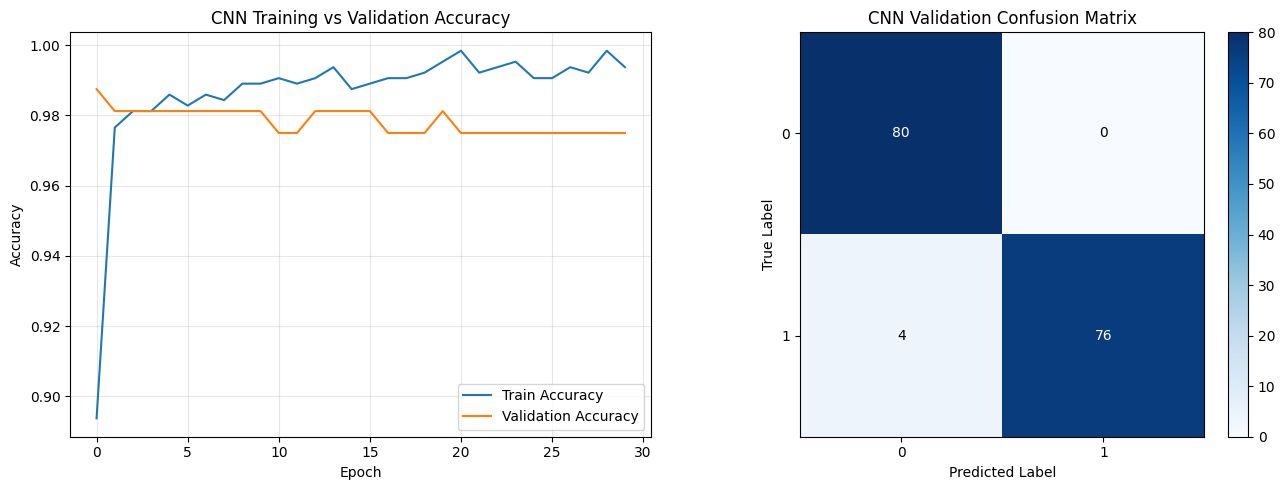

Saved consolidated metrics figure to: /home/claude/work/outputs/accuracy_loss_metrics.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

Path("./outputs").mkdir(parents=True, exist_ok=True)

y_pred_cnn_proba = cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: accuracy curves
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("CNN Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: confusion matrix
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("CNN Validation Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(
            j, i, str(cm[i, j]), ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
output_path = Path("./outputs/accuracy_loss_metrics.png")
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Saved consolidated metrics figure to: {output_path.resolve()}")

---
### Honest summary of what this notebook demonstrates

- The full preprocessing → baseline → CNN → evaluation pipeline runs
  end-to-end, with every number computed live from this run.
- All accuracy / classification-report / confusion-matrix figures above
  describe performance on the **synthetic prototype data only**.
- This notebook does **not** establish real-world voice classification
  accuracy. Treat it as proof that the engineering pipeline works, not
  as a model-quality result, until it has been re-run on real,
  properly licensed audio data.